# Valet Data Analysis

## Loading all the libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import *
import pandas as pd
from plotnine import *
import scipy.stats as st
from scipy.interpolate import interp1d
from matplotlib.ticker import MaxNLocator
%matplotlib inline

# Game Set for Analysis

Each game to evaluate should be on a different line in "games".

In [2]:
fileprefix = "../CardStock/output/Valet/"
outdir = "Valet/"
games = [
    {"game":"Agram","name":"Agram", "player":3},
    {"game":"Blackjack","name":"Blackjack", "player":1},
    {"game":"CrazyEights","name":"Crazy Eights", "player":3},
    {"game":"Cribbage","name":"Cribbage", "player":2},
    {"game":"Cuckoo","name":"Cuckoo", "player":6},
    {"game":"Euchre","name":"Euchre", "player":4},
    {"game":"GoFish","name":"Go Fish", "player":4},
    {"game":"GolfSix","name":"Golf-6", "player":4},
    {"game":"GOPS","name":"Goofspiel", "player":2},
    {"game":"Hearts","name":"Hearts", "player": 4},
    {"game":"Klaverjassen","name":"Klaverjassen", "player":4},
    {"game":"LeducPoker","name":"Leudec Hold'em", "player":2},
    {"game":"Pitch","name":"Pitch", "player":4},
    {"game":"President","name":"President", "player":5},
    {"game":"BlockRummy","name":"Rummy", "player":2},
    {"game":"Scarto","name":"Scarto", "player":3},
    {"game":"Schwimmen","name":"Schwimmen", "player":5},
    {"game":"Scopa","name":"Scopa", "player":2},
    {"game":"Skitgubbe","name":"Skitgubbe", "player":3},
    {"game":"Sueca","name":"Sueca", "player":4},
    {"game":"Whist","name":"Whist", "player":4},    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe["fileprefix"] = fileprefix
gameframe

,game,name,player,fileprefix
0,Agram,Agram,3,../CardStock/output/Valet/
1,Blackjack,Blackjack,1,../CardStock/output/Valet/
2,CrazyEights,Crazy Eights,3,../CardStock/output/Valet/
3,Cribbage,Cribbage,2,../CardStock/output/Valet/
4,Cuckoo,Cuckoo,6,../CardStock/output/Valet/
5,Euchre,Euchre,4,../CardStock/output/Valet/
6,GoFish,Go Fish,4,../CardStock/output/Valet/
7,GolfSix,Golf-6,4,../CardStock/output/Valet/
8,GOPS,Goofspiel,2,../CardStock/output/Valet/
9,Hearts,Hearts,4,../CardStock/output/Valet/


# Branching Factor

This first gathers data into a dataframe, which will enable us to draw graphs to show how the branching factor of the game changes over time.

This data is from games with all **random** players and games where the first player used a **MCTS** strategy.

In [3]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/choice.csv")
    print(row["game"])
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    if first:
        choiceframe = gf
        first = False
    else:
        choiceframe = pd.concat([choiceframe, gf])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "M" + "R" * (row["player"] - 1) + "/choice.csv")
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    choiceframe = pd.concat([choiceframe, gf])

Agram
Blackjack
CrazyEights
Cribbage
Cuckoo
Euchre
GoFish
GolfSix
GOPS
Hearts
Klaverjassen
LeducPoker
Pitch
President
BlockRummy
Scarto
Schwimmen
Scopa
Skitgubbe
Sueca
Whist


In [4]:
choiceframe.head()

,game,numPlayers,ai,imperfect,samples,tests,run,move,player,choices,choice,time,name
0,Agram,3,RRR,PRIVATE,10,1000,1,1,1,6,1,0,Agram
1,Agram,3,RRR,PRIVATE,10,1000,1,2,2,1,1,0,Agram
2,Agram,3,RRR,PRIVATE,10,1000,1,3,3,2,2,0,Agram
3,Agram,3,RRR,PRIVATE,10,1000,1,4,3,5,2,0,Agram
4,Agram,3,RRR,PRIVATE,10,1000,1,5,1,5,4,0,Agram


Individual games can be plotted.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/ChoicesBlockRummy.png


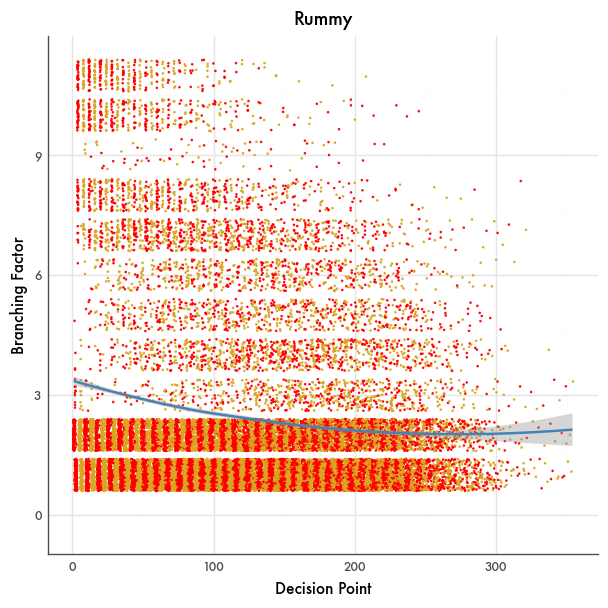

In [5]:
game = "BlockRummy"
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[(choiceframe["ai"].str.startswith("R")) & (choiceframe["game"] == game)], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.9)
 + geom_smooth(method="loess", color="steelblue")
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(6, 6))
 + theme(
        #plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='Decision Point', y='Branching Factor', title=gameframe[gameframe["game"]==game]["name"].item())
 + scale_colour_manual(values = ("red", "goldenrod", "limegreen", "cyan", "blue", "violet"))
)
cplot.save(outdir + "Choices"+game+".png")
cplot.show()

## Plotting all games

This plot shows the branching factors over all of the games in the testbed for random players.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/AllChoicesRandom.png


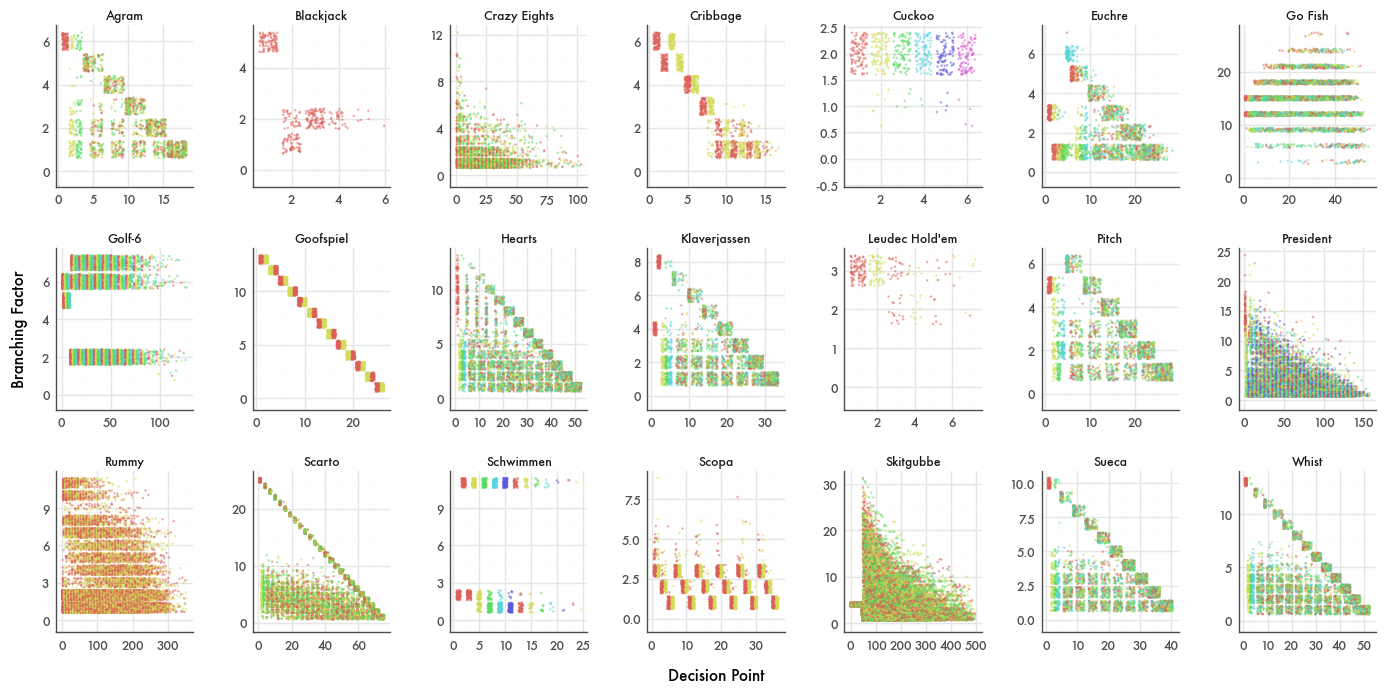

In [6]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("R")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.4)
 + facet_wrap("name", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
#        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        #axis_title=element_blank(),
        panel_spacing=0.02,
     
    )
 + labs(x='Decision Point', y='Branching Factor')

)
cplot.save(outdir + "AllChoicesRandom.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/ChoicesMCTS.png


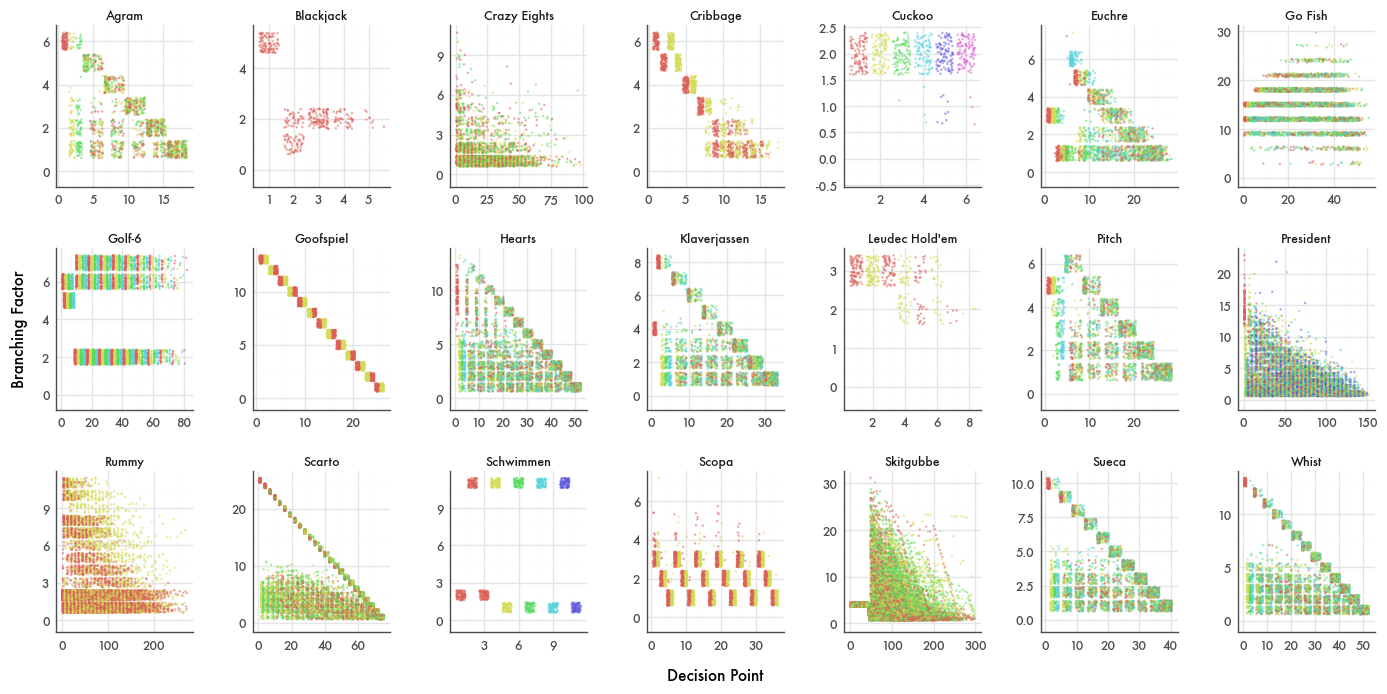

In [72]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("M")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.4)
 + facet_wrap("name", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        #plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        #axis_title=element_blank(),
        panel_spacing=0.02,
    )
 + labs(x='Decision Point', y='Branching Factor')
)
cplot.save(outdir + "ChoicesMCTS.png")
cplot.show()

And one plot that shows them all.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 20 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/Choices.png


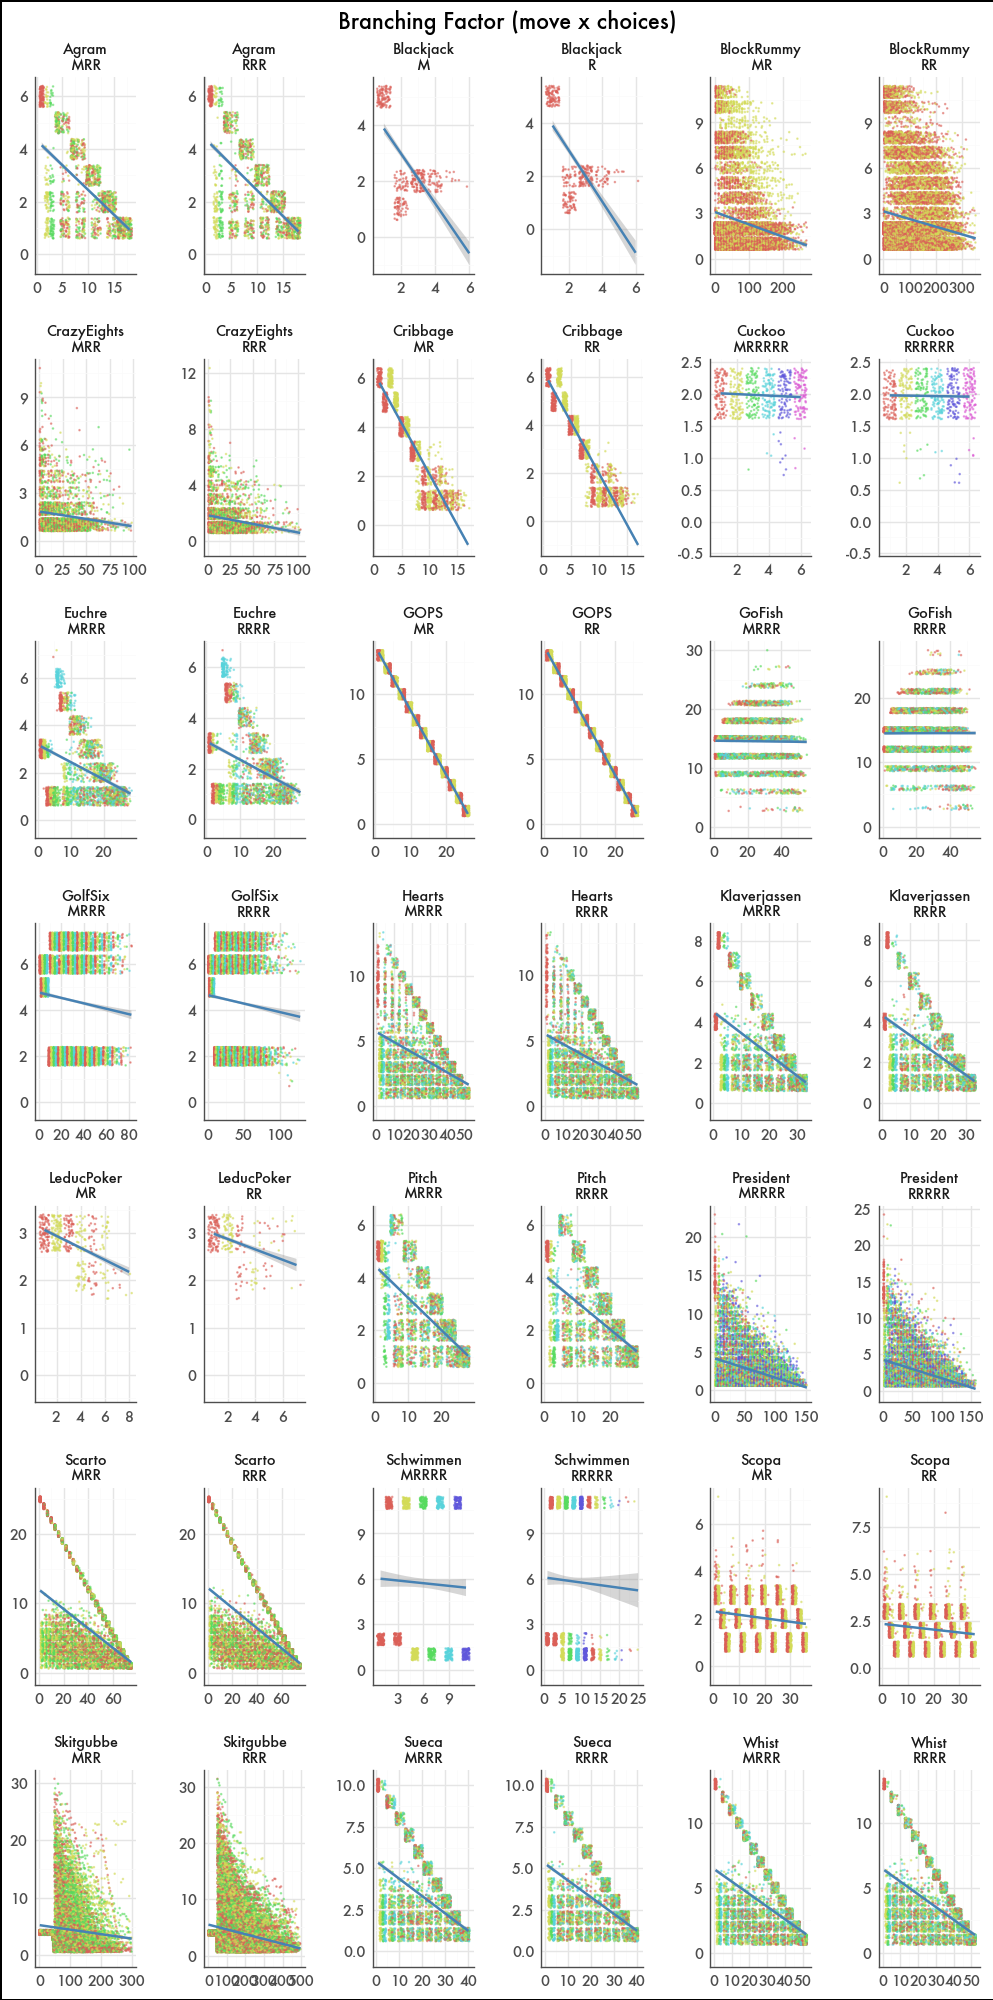

In [46]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe, aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 20))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save(outdir + "Choices.png")
cplot.show()

# Game Length

We can calculate the average game length, by finding the max value for the move column on each run, then averaging

In [7]:
ai = "R"
lengthframe = choiceframe[['name', 'run', 'move']][choiceframe["ai"].str.startswith(ai)].groupby(['name', 'run'], as_index=False)['move'].max()
lengthframe.head()

,name,run,move
0,Agram,1,18
1,Agram,2,18
2,Agram,3,18
3,Agram,4,18
4,Agram,5,18


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 5 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/LengthEuchre.png


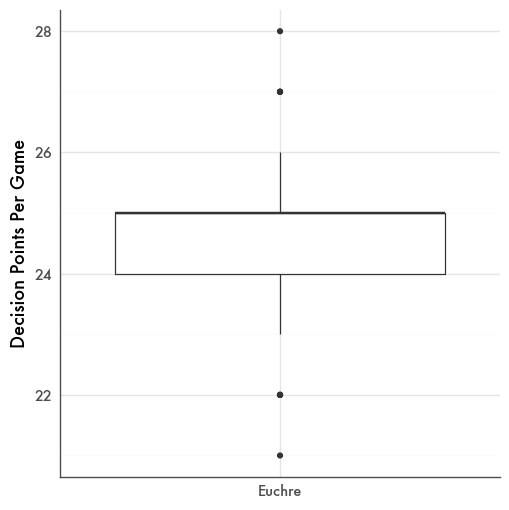

In [8]:
game = "Euchre"
lplot = (ggplot(lengthframe[lengthframe["name"]==game], aes("name", "move"))
 + geom_boxplot()
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(5, 5))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
# + scale_y_log10() 
 + labs(y="Decision Points Per Game", x="")
)
lplot.save(outdir + "Length"+ game +".png")
lplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/LengthR.png


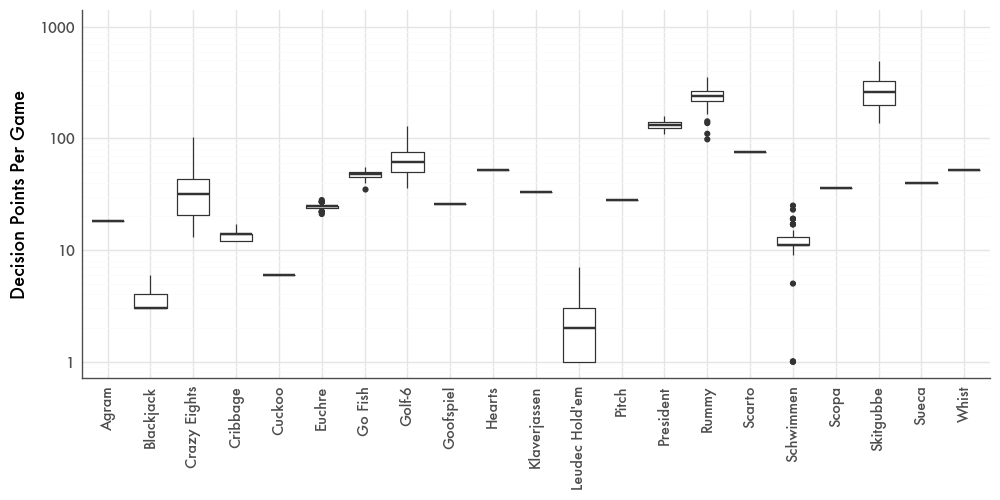

In [49]:
lplot = (ggplot(lengthframe, aes("name", "move"))
 + geom_boxplot()
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + scale_y_log10(limits=(1, 1000))        
 + labs(y="Decision Points Per Game", x="")
)
lplot.save(outdir + "Length" + ai + ".png")
lplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/LengthM.png


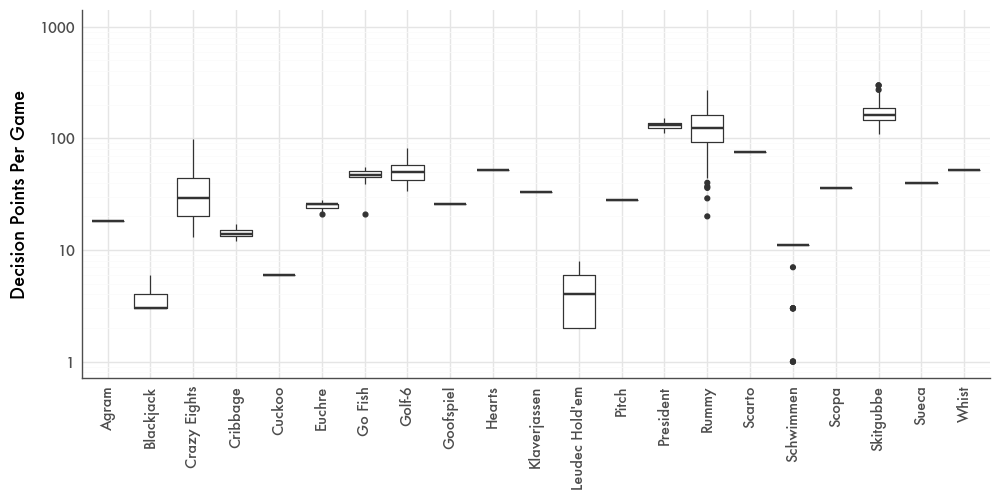

In [69]:
ai = "M"
lengthframe = choiceframe[['name', 'run', 'move']][choiceframe["ai"].str.startswith(ai)].groupby(['name', 'run'], as_index=False)['move'].max()
lplot = (ggplot(lengthframe, aes("name", "move"))
 + geom_boxplot()
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + scale_y_log10(limits=(1, 1000))        
 + labs(y="Decision Points Per Game", x="")
)
lplot.save(outdir + "Length" + ai + ".png")
lplot.show()

# Results

For random games, we want to look at the distribution of win/loss percentages across the players.

In [50]:
first = True
for index, row in gameframe.iterrows():
    print(row["game"])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    gf["ai"] = "Random"
    if first:
        resultsframe = gf
        first = False
    else:
        resultsframe = pd.concat([resultsframe, gf])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "M" + "R" * (row["player"] - 1) + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    gf["ai"] = "MCTS"
    resultsframe = pd.concat([resultsframe, gf])

resultsframe["player"] = resultsframe["player"].astype(str)
resultsframe["rank"] = resultsframe["rank"].astype(str)
resultsframe

Agram
Blackjack
CrazyEights
Cribbage
Cuckoo
Euchre
GoFish
GolfSix
GOPS
Hearts
Klaverjassen
LeducPoker
Pitch
President
BlockRummy
Scarto
Schwimmen
Scopa
Skitgubbe
Sueca
Whist


,game,numPlayers,ai,imperfect,samples,tests,run,player,score,rank,time,name
0,Agram,3,Random,PRIVATE,10,1000,1,1,1.0,1,21.1870,Agram
1,Agram,3,Random,PRIVATE,10,1000,1,2,0.0,2,21.1870,Agram
2,Agram,3,Random,PRIVATE,10,1000,1,3,0.0,2,21.1870,Agram
3,Agram,3,Random,PRIVATE,10,1000,2,1,0.0,2,2.5796,Agram
4,Agram,3,Random,PRIVATE,10,1000,2,2,1.0,1,2.5796,Agram
...,...,...,...,...,...,...,...,...,...,...,...,...
395,Whist,4,MCTS,PRIVATE,10,1000,99,4,0.0,3,38929.3228,Whist
396,Whist,4,MCTS,PRIVATE,10,1000,100,1,0.0,3,26795.8644,Whist
397,Whist,4,MCTS,PRIVATE,10,1000,100,2,1.0,1,26795.8644,Whist
398,Whist,4,MCTS,PRIVATE,10,1000,100,3,0.0,3,26795.8644,Whist


# Timing

In [51]:
pgames = resultsframe[['name', 'run', 'ai', 'time']]
what = pgames.groupby(['name', 'run', 'ai'], as_index=False)['time'].max()
timef = what.groupby(['name', 'ai'], as_index=False).median()[['name', 'time', 'ai']]
timef

,name,time,ai
0,Agram,5079.28230,MCTS
1,Agram,2.83570,Random
2,Blackjack,633.40570,MCTS
3,Blackjack,0.73020,Random
4,Crazy Eights,11235.64635,MCTS
5,Crazy Eights,2.88255,Random
6,Cribbage,7841.34050,MCTS
7,Cribbage,2.00580,Random
8,Cuckoo,728.84520,MCTS
9,Cuckoo,1.01105,Random


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/Time.png


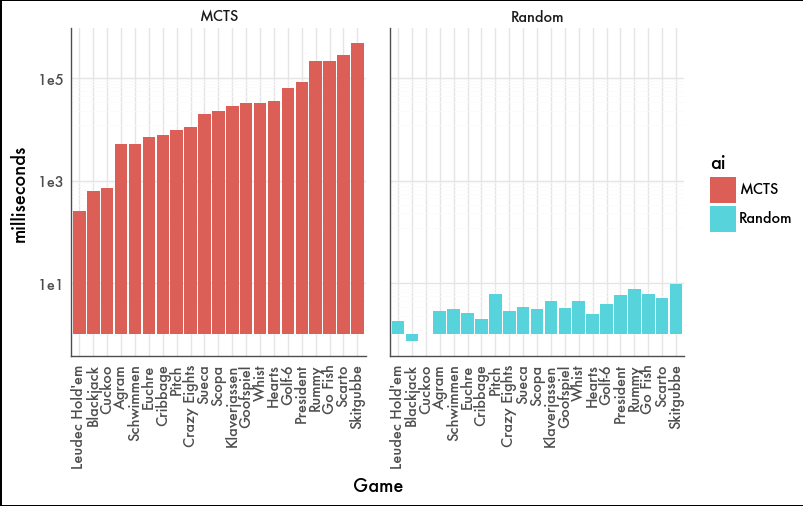

In [52]:
rplot = (ggplot(timef, aes("reorder(name, time)", "time", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap(["ai"])
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='Game', y='milliseconds')
 + scale_y_log10()
)
rplot.save(outdir + "Time.png")
rplot.show()

In [53]:
rf2 = resultsframe.groupby(['name', 'player', 'rank', 'ai'], as_index=False).count()
rf3 = rf2[(rf2["player"]=="1") & (rf2["rank"] == "1")][["name", "ai", "run"]]
rf3["run"] = rf3["run"] / 100
rf4 = rf3.pivot(index='name', columns='ai')
rf4 = rf4["run"].reset_index()
rf4.columns.name=None
rf5 = rf4.merge(gameframe, on='name', how='left')
rf5

,name,MCTS,Random,game,player,fileprefix
0,Agram,0.51,0.31,Agram,3,../CardStock/output/Valet/
1,Blackjack,1.00,1.00,Blackjack,1,../CardStock/output/Valet/
2,Crazy Eights,0.43,0.41,CrazyEights,3,../CardStock/output/Valet/
3,Cribbage,0.92,0.83,Cribbage,2,../CardStock/output/Valet/
4,Cuckoo,0.93,0.84,Cuckoo,6,../CardStock/output/Valet/
5,Euchre,0.61,0.46,Euchre,4,../CardStock/output/Valet/
6,Go Fish,0.38,0.35,GoFish,4,../CardStock/output/Valet/
7,Golf-6,0.86,0.24,GolfSix,4,../CardStock/output/Valet/
8,Goofspiel,0.88,0.50,GOPS,2,../CardStock/output/Valet/
9,Hearts,0.68,0.24,Hearts,4,../CardStock/output/Valet/


In [54]:
def fairness(wp, np):
    if np == 1:
        return 1
    if wp < 1 / np:
        return wp * np
    else:
        return (np - np * wp) / (np - 1)
rf5["fairness"] = rf5.apply(lambda x: fairness(x.Random, x.player), axis=1)
def order(aiwp, np):
    if np == 1:
        return 1
    ewp = 1 / np
    return (aiwp - ewp) / (1 - ewp)
rf5["order"] = rf5.apply(lambda x: order(x.MCTS, x.player), axis=1)
rf5["gain"] = rf5.apply(lambda x: x.MCTS - x.Random, axis=1)
rf5

,name,MCTS,Random,game,player,fileprefix,fairness,order,gain
0,Agram,0.51,0.31,Agram,3,../CardStock/output/Valet/,0.930000,0.265000,0.20
1,Blackjack,1.00,1.00,Blackjack,1,../CardStock/output/Valet/,1.000000,1.000000,0.00
2,Crazy Eights,0.43,0.41,CrazyEights,3,../CardStock/output/Valet/,0.885000,0.145000,0.02
3,Cribbage,0.92,0.83,Cribbage,2,../CardStock/output/Valet/,0.340000,0.840000,0.09
4,Cuckoo,0.93,0.84,Cuckoo,6,../CardStock/output/Valet/,0.192000,0.916000,0.09
5,Euchre,0.61,0.46,Euchre,4,../CardStock/output/Valet/,0.720000,0.480000,0.15
6,Go Fish,0.38,0.35,GoFish,4,../CardStock/output/Valet/,0.866667,0.173333,0.03
7,Golf-6,0.86,0.24,GolfSix,4,../CardStock/output/Valet/,0.960000,0.813333,0.62
8,Goofspiel,0.88,0.50,GOPS,2,../CardStock/output/Valet/,1.000000,0.760000,0.38
9,Hearts,0.68,0.24,Hearts,4,../CardStock/output/Valet/,0.960000,0.573333,0.44


In [55]:
gameframe = gameframe.merge(rf5[["name", "fairness", "order", "gain", "MCTS"]], on="name", how="left")

In [56]:
gameframe

,game,name,player,fileprefix,fairness,order,gain,MCTS
0,Agram,Agram,3,../CardStock/output/Valet/,0.930000,0.265000,0.20,0.51
1,Blackjack,Blackjack,1,../CardStock/output/Valet/,1.000000,1.000000,0.00,1.00
2,CrazyEights,Crazy Eights,3,../CardStock/output/Valet/,0.885000,0.145000,0.02,0.43
3,Cribbage,Cribbage,2,../CardStock/output/Valet/,0.340000,0.840000,0.09,0.92
4,Cuckoo,Cuckoo,6,../CardStock/output/Valet/,0.192000,0.916000,0.09,0.93
5,Euchre,Euchre,4,../CardStock/output/Valet/,0.720000,0.480000,0.15,0.61
6,GoFish,Go Fish,4,../CardStock/output/Valet/,0.866667,0.173333,0.03,0.38
7,GolfSix,Golf-6,4,../CardStock/output/Valet/,0.960000,0.813333,0.62,0.86
8,GOPS,Goofspiel,2,../CardStock/output/Valet/,1.000000,0.760000,0.38,0.88
9,Hearts,Hearts,4,../CardStock/output/Valet/,0.960000,0.573333,0.44,0.68


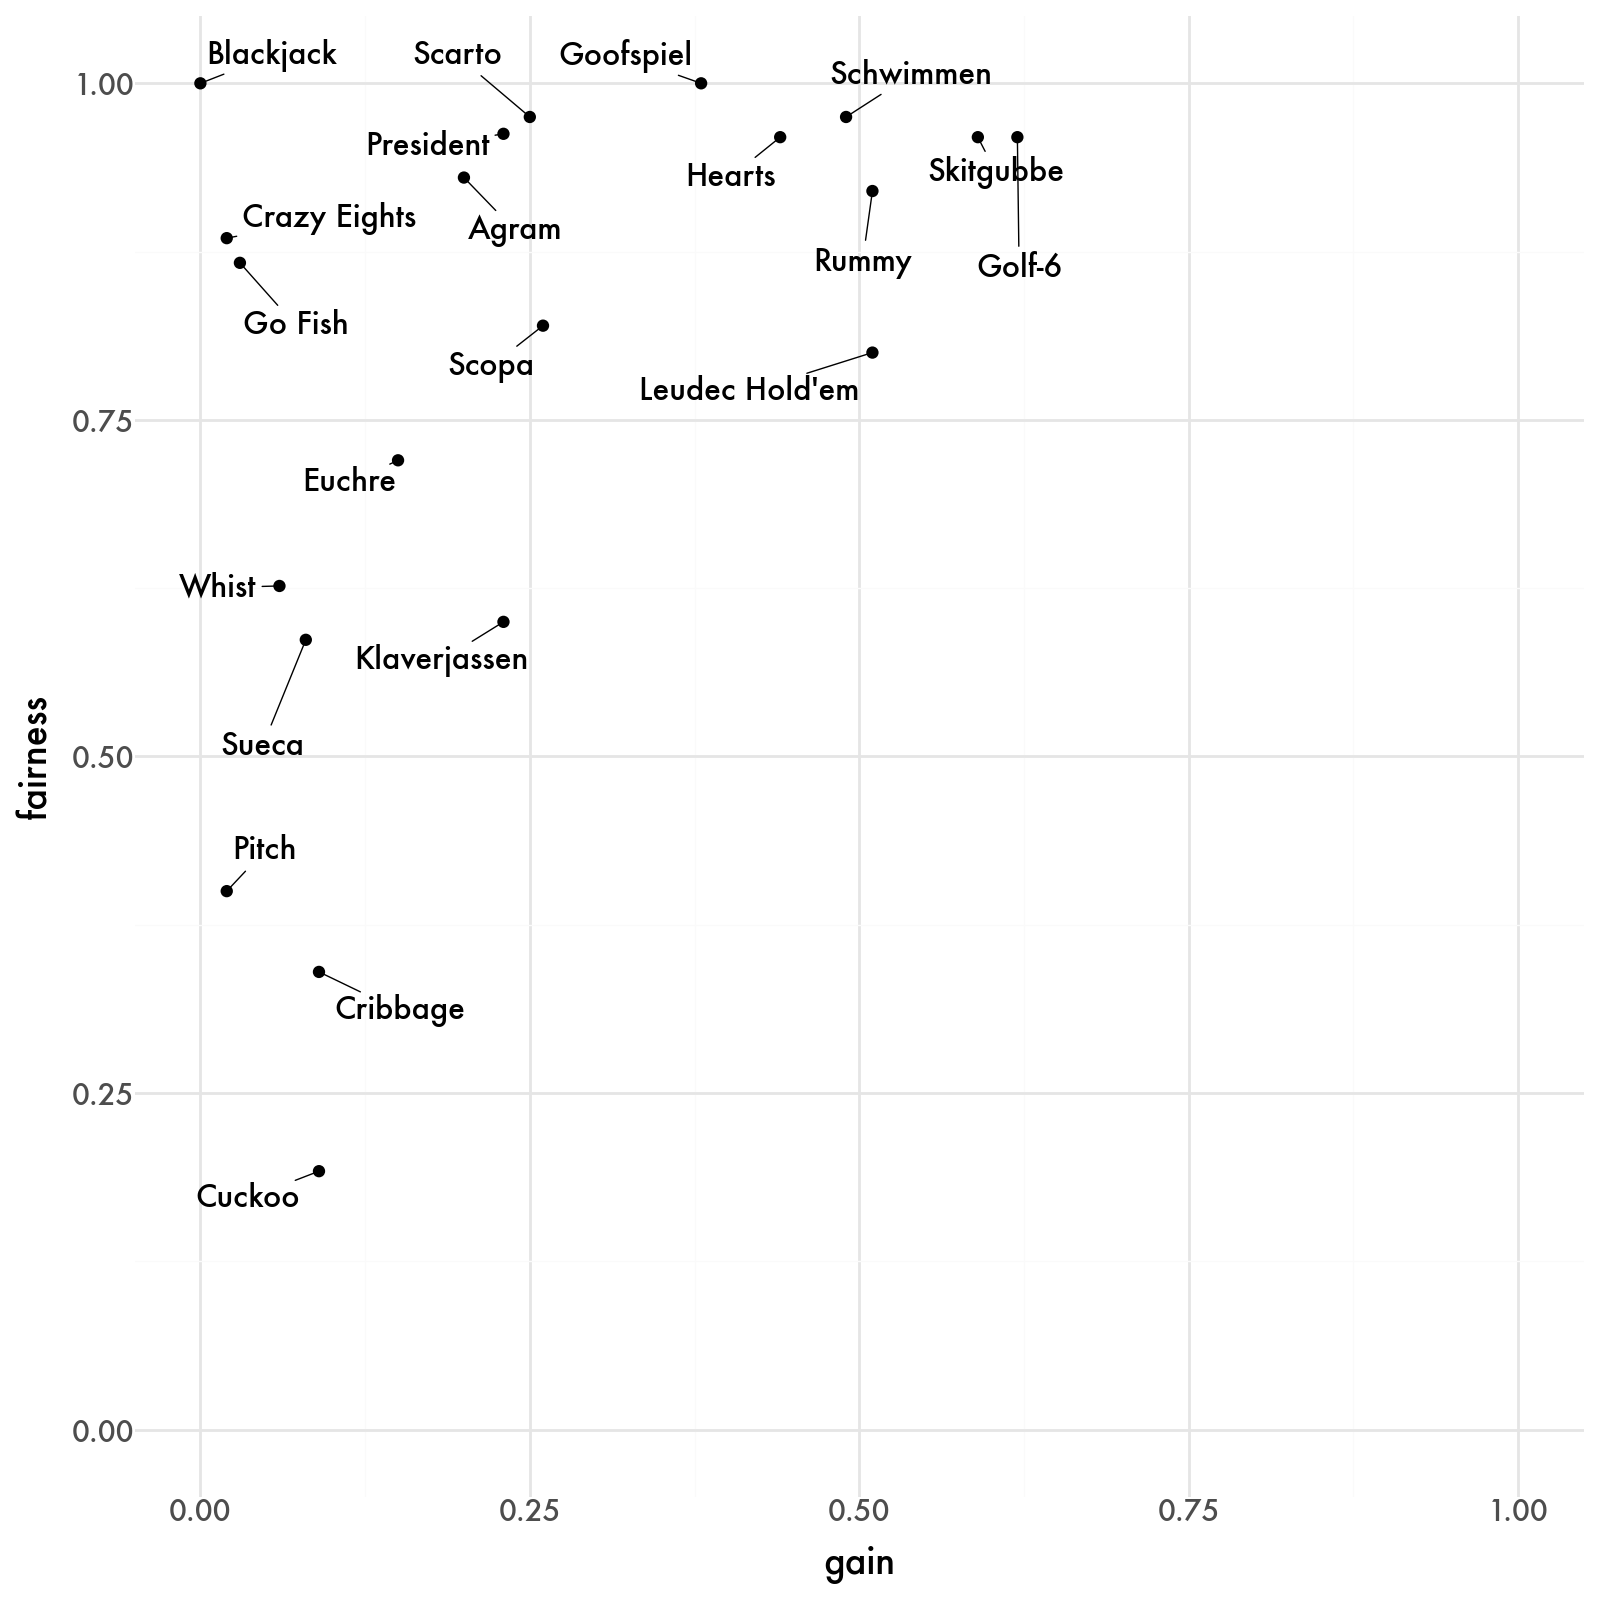

In [57]:
(ggplot(gameframe, aes("gain", "fairness", label="name"))
 + geom_point()
 + xlim(0, 1)
 + ylim(0, 1)
 + geom_text(adjust_text={"arrowprops": {"arrowstyle": "-"}})
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 8))
)

In [58]:
rf6 = rf3.merge(gameframe[["game", "name", "gain", "player"]], on='name', how='left')
rf6.sort_values(by=['gain'])

,name,ai,run,game,gain,player
2,Blackjack,MCTS,1.00,Blackjack,0.00,1
3,Blackjack,Random,1.00,Blackjack,0.00,1
25,Pitch,Random,0.70,Pitch,0.02,4
4,Crazy Eights,MCTS,0.43,CrazyEights,0.02,3
5,Crazy Eights,Random,0.41,CrazyEights,0.02,3
24,Pitch,MCTS,0.72,Pitch,0.02,4
13,Go Fish,Random,0.35,GoFish,0.03,4
12,Go Fish,MCTS,0.38,GoFish,0.03,4
41,Whist,Random,0.53,Whist,0.06,4
40,Whist,MCTS,0.59,Whist,0.06,4


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/Ranks.png


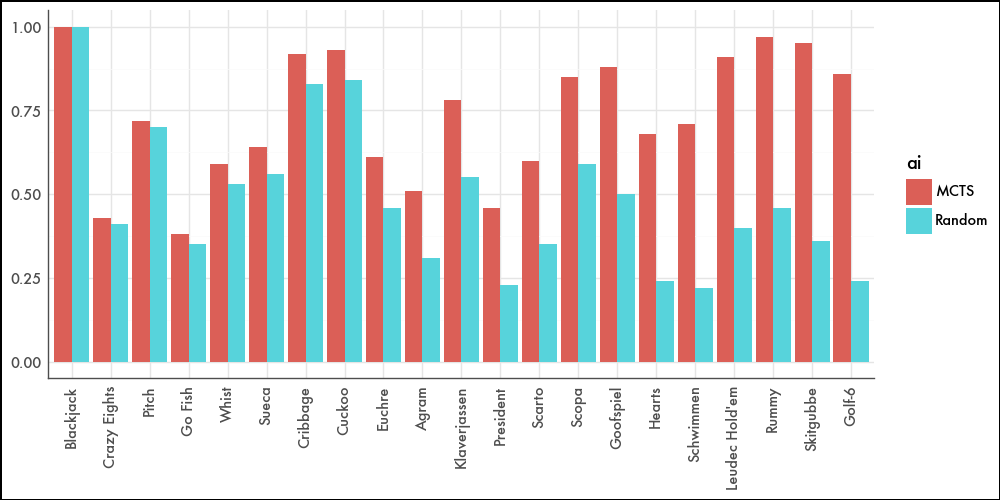

In [59]:
rplot = (ggplot(rf6, aes('reorder(name, gain)', "run", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 1)
 + labs(x='player', y='rank')
)
rplot.save(outdir + "Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/RandomScores.png


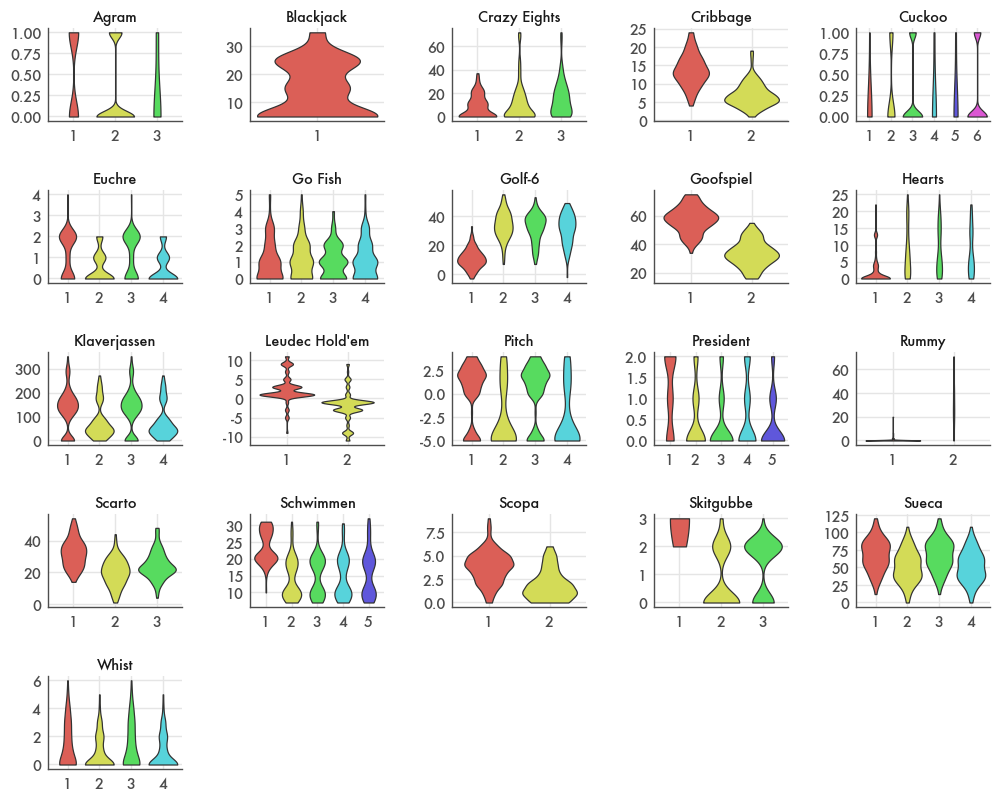

In [60]:
splot = (ggplot(resultsframe[resultsframe["ai"].str.startswith("M")], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("name", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
 + scale_y_continuous(minor_breaks=False)
)
splot.save(outdir + "RandomScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 12 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/RGolfSixScores.png


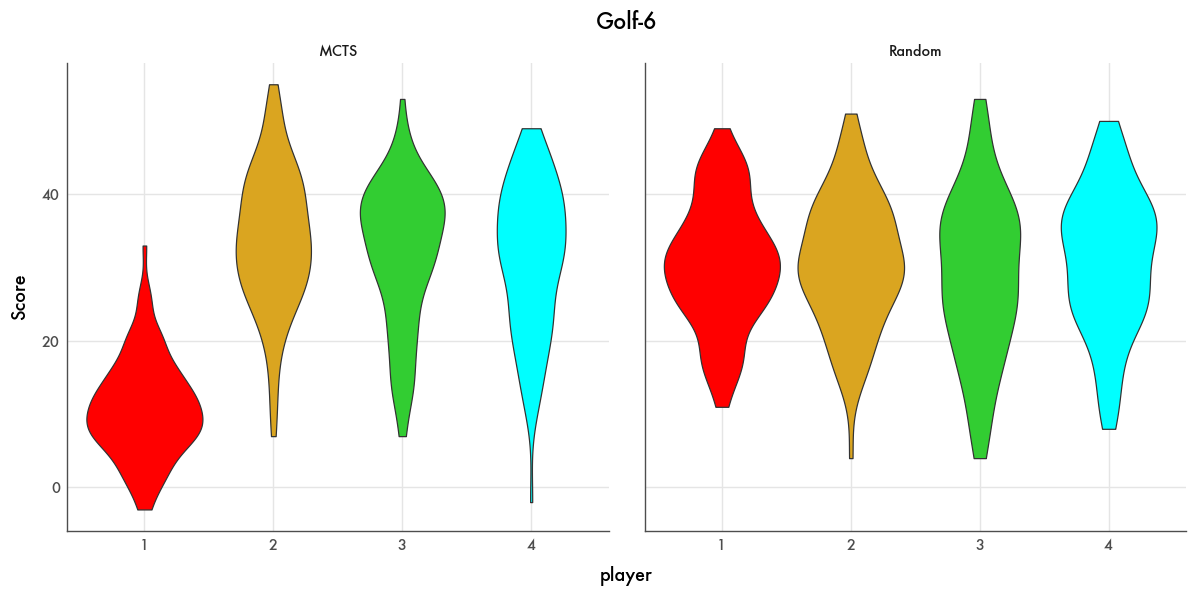

In [61]:
game = "GolfSix"
ai = "R"
splot = (ggplot(resultsframe[(resultsframe["game"] == game)], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("ai")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(12, 6))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        #axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='Score', title=gameframe[gameframe["game"]==game]["name"].item())
 + scale_y_continuous(minor_breaks=False)
 + scale_fill_manual(values = ("red", "goldenrod", "limegreen", "cyan", "blue", "violet"))
)
splot.save(outdir + ai + game + "Scores.png")
splot.show()

In [62]:
resultsframe[(resultsframe["ai"].str.startswith(ai)) & (resultsframe["game"] == game)& (resultsframe["player"] == "2")]["score"]

1      25.0
5      31.0
9      16.0
13     26.0
17     39.0
       ... 
381    34.0
385    20.0
389    37.0
393    51.0
397    16.0
Name: score, Length: 100, dtype: float64

In [63]:
resultsframe

,game,numPlayers,ai,imperfect,samples,tests,run,player,score,rank,time,name
0,Agram,3,Random,PRIVATE,10,1000,1,1,1.0,1,21.1870,Agram
1,Agram,3,Random,PRIVATE,10,1000,1,2,0.0,2,21.1870,Agram
2,Agram,3,Random,PRIVATE,10,1000,1,3,0.0,2,21.1870,Agram
3,Agram,3,Random,PRIVATE,10,1000,2,1,0.0,2,2.5796,Agram
4,Agram,3,Random,PRIVATE,10,1000,2,2,1.0,1,2.5796,Agram
...,...,...,...,...,...,...,...,...,...,...,...,...
395,Whist,4,MCTS,PRIVATE,10,1000,99,4,0.0,3,38929.3228,Whist
396,Whist,4,MCTS,PRIVATE,10,1000,100,1,0.0,3,26795.8644,Whist
397,Whist,4,MCTS,PRIVATE,10,1000,100,2,1.0,1,26795.8644,Whist
398,Whist,4,MCTS,PRIVATE,10,1000,100,3,0.0,3,26795.8644,Whist


In [64]:
rf2 = resultsframe[resultsframe["ai"].str.startswith("M")].groupby(['game', 'player', 'rank'], as_index=False).count()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/AIRanks.png


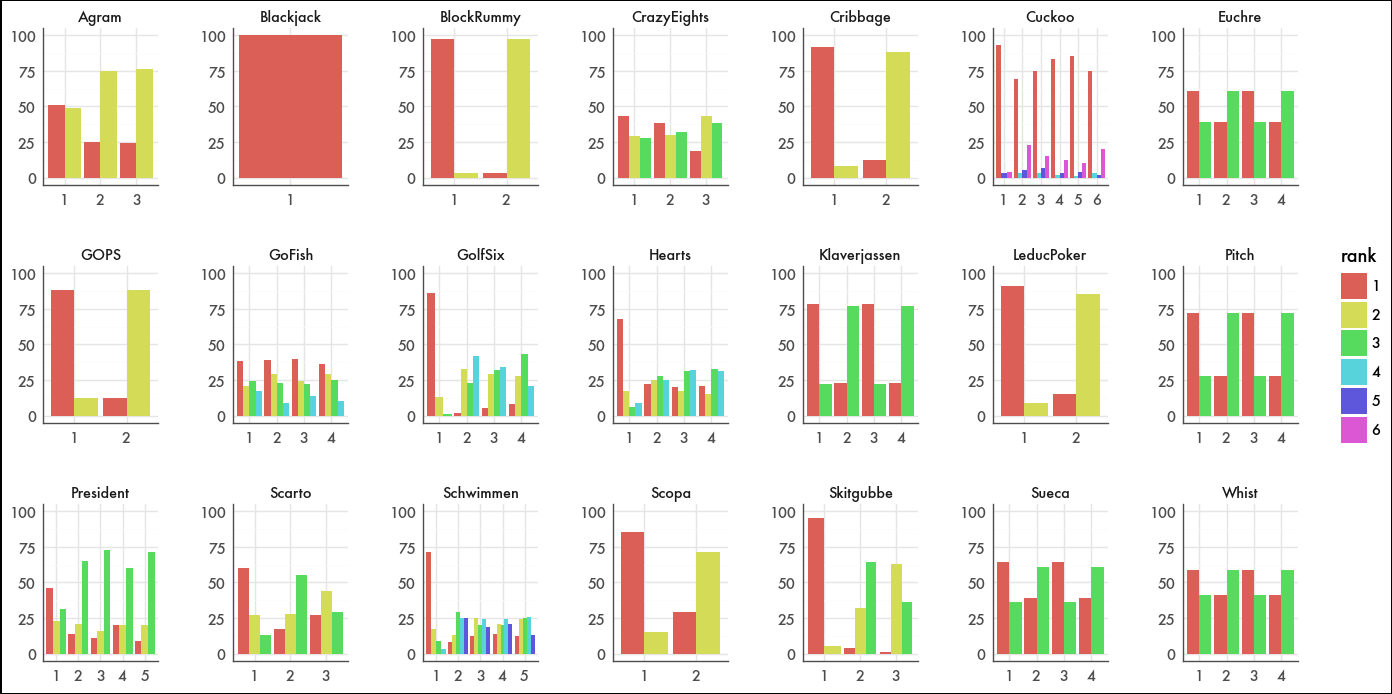

In [87]:
rplot = (ggplot(rf2, aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 7))
 + ylim(0, 100)
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
)
rplot.save(outdir + "AIRanks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/PvsRScores.png


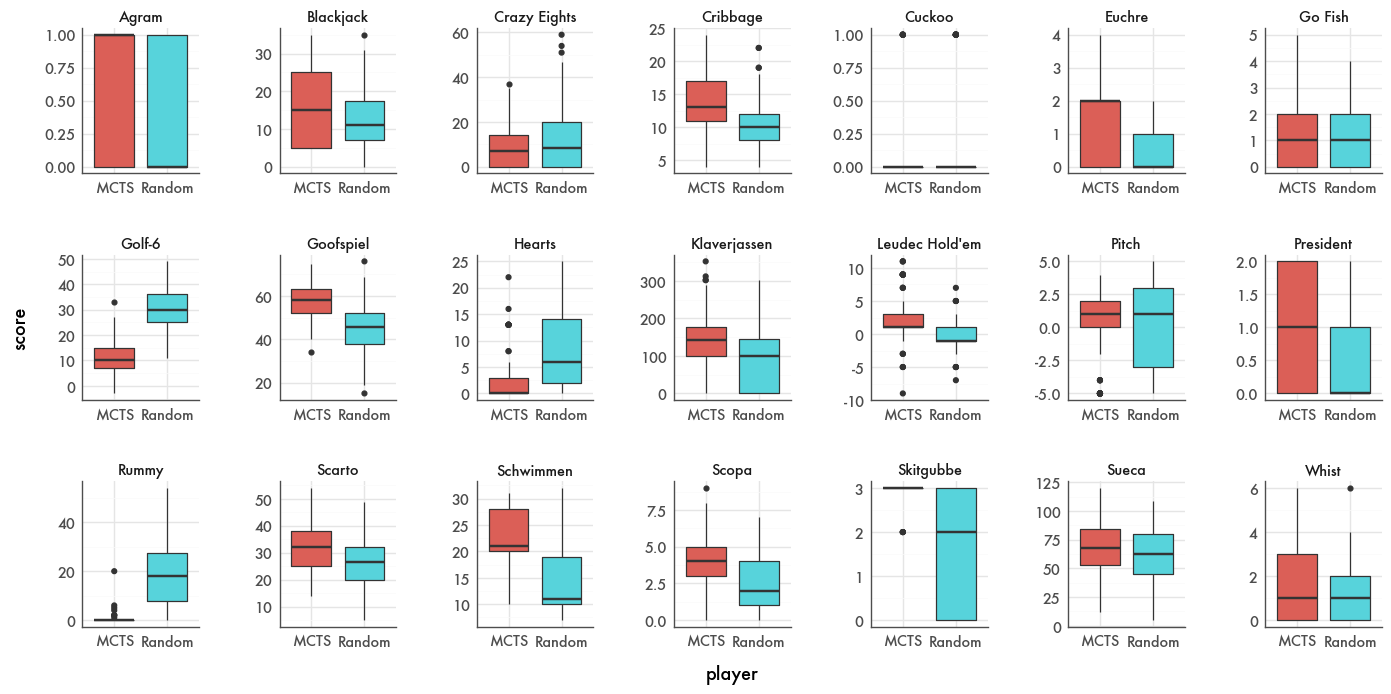

In [88]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="ai"))
 + geom_boxplot()
 + facet_wrap("name", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save(outdir + "PvsRScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Valet/MvsRScores.png


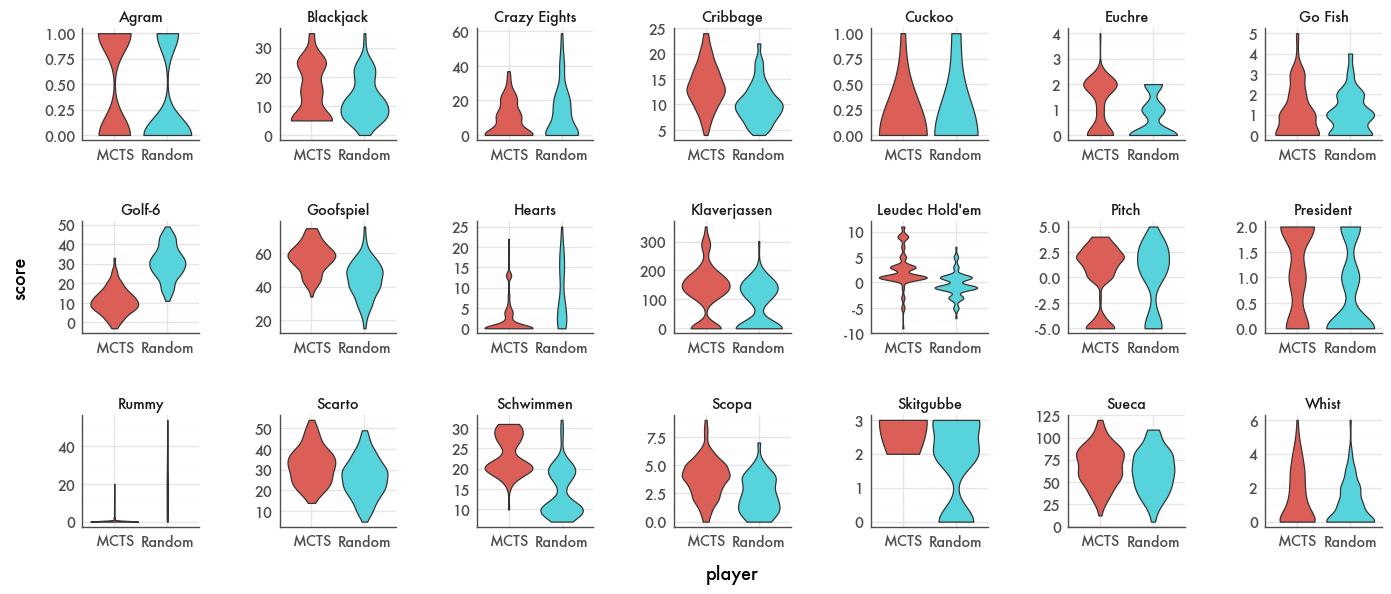

In [67]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="ai"))
 + geom_violin()
 + facet_wrap("name", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 6))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save(outdir + "MvsRScores.png")
splot.show()

In [68]:
def sig_code(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    elif pval < 0.1:
        return "."
    else:
        return ""
comp = resultsframe[resultsframe["player"]=="1"][["game", "ai", "run", "score"]]
comp = comp.pivot(index=["game", "run"], columns="ai", values="score")
comp2 = comp.groupby("game").apply(lambda df: st.ttest_ind(df['MCTS'], df['Random'])[1]).reset_index().rename(columns={0:"p-value"})[["game", "p-value"]]
comp3 = comp.groupby('game').apply(lambda df: sig_code(st.ttest_ind(df['MCTS'], df['Random'])[1])).reset_index().rename(columns={0:"significance"})
comp4 = comp3.merge(comp2, on="game", how="left").sort_values(by="p-value")
comp4

,game,significance,p-value
9,GolfSix,***,2.145819e-43
2,BlockRummy,***,1.709290e-28
16,Schwimmen,***,9.145256e-27
18,Skitgubbe,***,1.023618e-17
7,GOPS,***,1.374494e-16
10,Hearts,***,3.974301e-11
12,LeducPoker,***,4.471130e-11
17,Scopa,***,6.255608e-09
4,Cribbage,***,1.250729e-08
11,Klaverjassen,***,5.859629e-06
